# Allesina et al. (2015) — Food Web Stability

Reproduction of the main results from:

> Allesina, Grilli, Barabas, Tang, Aljadeff & Maritan (2015). *Predicting the stability of large structured food webs.* Nature Communications 6:7842

**Notebook structure:**
- **Cell 1** — All functions (models, approximation, comparison)
- **Cell 2** — Figure 1: spectrum in the complex plane
- **Cell 3** — Figure 2: predicted vs observed (cascade, niche, empirical)
- **Cell 4** — Figure 3: cascade model variants
- **Cell 5** — Figure 4: sensitivity analysis


## Cell 1 — All functions

Run this cell before all the others.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches


# 1. Cascade model

def cascade_model(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K = np.zeros((S, S), dtype=int)
    iu = np.triu_indices(S, k=1)
    draws = rng.random(len(iu[0])) < C
    K[iu[0][draws], iu[1][draws]] = 1
    return K

# 2. Niche model

def niche_model(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    n = np.sort(rng.random(S))
    beta_param = max(1.0 / (2 * C) - 1.0, 0.01)
    r = rng.beta(1.0, beta_param, size=S) * n
    c_center = rng.uniform(r / 2.0, n)
    lo = c_center - r / 2.0
    hi = c_center + r / 2.0
    K = np.zeros((S, S), dtype=int)
    for j in range(S):
        mask = (np.arange(S) != j) & (lo[j] <= n) & (n <= hi[j])
        K[mask, j] = 1
    return K



def cascade_niche_degdist(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K_niche = niche_model(S, C, rng)
    consumer_degrees = K_niche.sum(axis=0)
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(int(consumer_degrees[j]), j)
        if n_prey > 0:
            chosen = rng.choice(j, size=n_prey, replace=False)
            K[chosen, j] = 1
    return K

def cascade_interval(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(rng.binomial(j, C), j)
        if n_prey > 0:
            start = rng.integers(0, j - n_prey + 1)
            K[start:start + n_prey, j] = 1
    return K

def cascade_niche_degdist_interval(S, C, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    K_niche = niche_model(S, C, rng)
    consumer_degrees = K_niche.sum(axis=0)
    K = np.zeros((S, S), dtype=int)
    for j in range(1, S):
        n_prey = min(int(consumer_degrees[j]), j)
        if n_prey > 0:
            start = rng.integers(0, j - n_prey + 1)
            K[start:start + n_prey, j] = 1
    return K


def build_M_from_K(K, sampler, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    S = K.shape[0]
    M = np.zeros((S, S))
    iu = np.triu_indices(S, k=1)
    mask = K[iu[0], iu[1]] == 1
    rows, cols = iu[0][mask], iu[1][mask]
    n_pairs = len(rows)
    if n_pairs == 0:
        return M
    xy = sampler(n_pairs, rng)
    M[rows, cols] = xy[:, 0]
    M[cols, rows] = xy[:, 1]
    return M

def default_bivariate_sampler(mu_x=-1.0, mu_y=0.35,
                               sigma_x=0.71, sigma_y=0.71,
                               rho_xy=-0.67):
    def sampler(n, rng):
        cov = rho_xy * sigma_x * sigma_y
        cov_matrix = np.array([[sigma_x**2, cov], [cov, sigma_y**2]])
        mean = np.array([mu_x, mu_y])
        xy = rng.multivariate_normal(mean, cov_matrix, size=n)
        xy[:, 0] = -np.abs(xy[:, 0])
        xy[:, 1] =  np.abs(xy[:, 1])
        return xy
    return sampler


def triangular_stats(M):
    S = M.shape[0]
    iu = np.triu_indices(S, k=1)
    upper_vals = M[iu[0], iu[1]]
    lower_vals = M[iu[1], iu[0]]
    
    mu_U = upper_vals.mean()
    mu_L = lower_vals.mean()
    sigma_U2 = upper_vals.var()
    sigma_L2 = lower_vals.var()
    rho_UL = np.corrcoef(upper_vals, lower_vals)[0, 1] if len(upper_vals) > 1 else 0.0
    
    return mu_U, mu_L, sigma_U2, sigma_L2, rho_UL


def spectrum_A_params(S, mu_U, mu_L):
    ratio = (-mu_L / mu_U)
    denom = ratio**(2.0 / S) - 1.0
    r_A = (mu_U - mu_L) * ratio**(1.0 / S) / denom
    c_A = (mu_L - mu_U) * ratio**(2.0 / S) / denom
    re_lambda_A1 = r_A + c_A - mu_L
    return r_A, c_A, re_lambda_A1

def spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL):
    sigma_U = np.sqrt(sigma_U2)
    sigma_L = np.sqrt(sigma_L2)
    a = S if np.isclose(sigma_U2, sigma_L2) else S * (sigma_U2 - sigma_L2) / np.log(sigma_U2 / sigma_L2)
    cov_term = rho_UL * sigma_U * sigma_L * (S - 1)
    r_h_B = (a + cov_term) / np.sqrt(a)
    r_v_B = (a - cov_term) / np.sqrt(a)
    return r_h_B, r_v_B

def predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL):
    _, _, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, _ = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    return re_lambda_A1 + r_h_B

def re_lambda_M1_from_Z_params(S, C, mu_x, mu_y, sigma_x, sigma_y, rho_xy):
    sigma_U2 = (sigma_x ** 2) * C
    sigma_L2 = (sigma_y ** 2) * C
    _, _, re_lambda_A1 = spectrum_A_params(S, mu_x, mu_y)
    r_h_B, _ = spectrum_B_params(S, sigma_U2, sigma_L2, rho_xy)
    return re_lambda_A1 + r_h_B


def may_criterion(S, C, mean_abs_M, var_M):
    return np.sqrt(S * C) * np.sqrt(var_M)

def tang_criterion(S, C, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL):
    sigma = np.sqrt((sigma_U2 + sigma_L2) / 2.0)
    return np.sqrt(S * C) * sigma * (1.0 + rho_UL)


def leading_eigenvalue_real_part(M):
    eigvals = np.linalg.eigvals(M)
    return eigvals[np.argmax(eigvals.real)].real, eigvals

def most_upper_triangular_order(K):
    S = K.shape[0]
    remaining = list(range(S))
    order = []
    while remaining:
        rem_arr = np.array(remaining)
        sub = K[np.ix_(rem_arr, rem_arr)]
        idx = int(np.argmax(sub.sum(axis=1)))
        order.append(remaining[idx])
        remaining.pop(idx)
    return np.array(order)



def best_upper_triangular_order(K):
    """Restituisce K riordinata solo se il greedy migliora la triangolarità
    rispetto all'ordine originale, altrimenti restituisce K invariata."""
    S = K.shape[0]
    iu = np.triu_indices(S, k=1)
    il = np.tril_indices(S, k=-1)

    def tau(K_):
        n_upper = K_[iu].sum()
        n_lower = K_[il].sum()
        total = n_upper + n_lower
        return n_upper / total if total > 0 else 0.5

    order = most_upper_triangular_order(K)
    K_reordered = K[np.ix_(order, order)]

    if tau(K_reordered) >= tau(K):
        return K_reordered
    return K

Libreria caricata correttamente.


## Figure 1 — Spectrum in the complex plane

Eigenvalues of **M** compared with the theoretical circle for **A** and the theoretical ellipse for **B** (centered at Re(λ_A,1)).
Reproduction of Fig. 1b from Allesina et al. (2015).


Re(λ_M,1) osservato = 2.3630  |  predetto = 2.4379


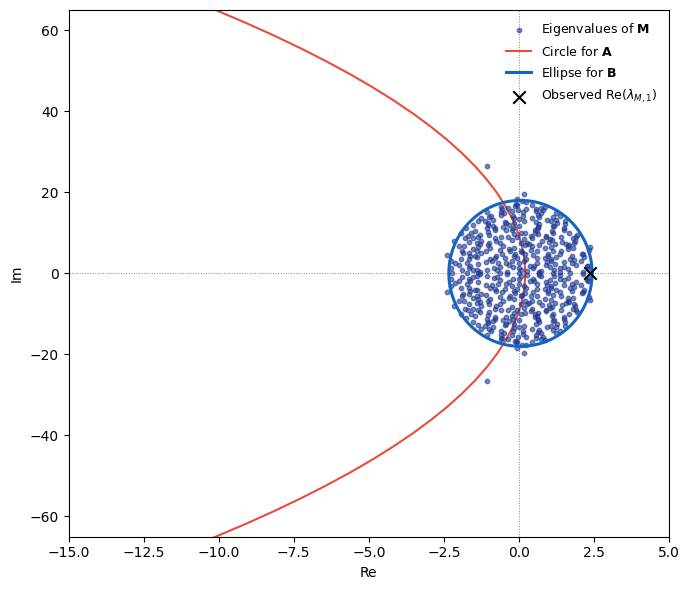

In [18]:

S, C, seed = 500, 0.25, 0

rng = np.random.default_rng(seed)
sampler = default_bivariate_sampler()

K = cascade_model(S, C, rng)
M = build_M_from_K(K, sampler, rng)

mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
r_A, c_A, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
r_h_B, r_v_B           = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
obs, eigvals            = leading_eigenvalue_real_part(M)
pred                    = re_lambda_A1 + r_h_B

print(f"Re(λ_M,1) osservato = {obs:.4f}  |  predetto = {pred:.4f}")


fig, ax = plt.subplots(figsize=(7, 6))
theta = np.linspace(0, 2 * np.pi, 400)

ax.scatter(eigvals.real, eigvals.imag, s=10, c='#1f3a93',
           alpha=0.6, label=r'Eigenvalues of $\mathbf{M}$', zorder=3)
ax.plot(c_A + r_A * np.cos(theta), r_A * np.sin(theta),
        color='#e74c3c', linewidth=1.5, label=r'Circle for $\mathbf{A}$')
ax.plot(re_lambda_A1 + r_h_B * np.cos(theta), r_v_B * np.sin(theta),
        color='#1565c0', linewidth=2.2, label=r'Ellipse for $\mathbf{B}$', zorder=5)
ax.scatter([obs], [0], color='black', marker='x', s=80, zorder=6,
           label=r'Observed Re($\lambda_{M,1}$)')
ax.axvline(0, color='gray', linewidth=0.7, linestyle=':')
ax.axhline(0, color='gray', linewidth=0.7, linestyle=':')

ax.set_xlabel('Re');  ax.set_ylabel('Im')
ax.legend(frameon=False, loc='upper right', fontsize=9)
ax.set_xlim(-15, 5);  ax.set_ylim(-65, 65)
fig.tight_layout()
plt.show()


## Figure 2 — Predicted vs Observed Re(λ₁) + spectra in the complex plane

Six panels as in the original Fig. 2:
- **(a,b,c)** scatter of predicted vs observed for cascade, niche, and empirical food webs
- **(d,e,f)** spectra in the complex plane for one example of each type

Parameters: `n_cascade=60`, `n_niche=30`, `n_empirical=15×10`.
Increase `n_cascade` and `n_niche` up to 150 to exactly replicate the paper.


  [cascade]   1/50  S=1000  C=0.154  obs=2.526  pred=2.629
  [cascade]   2/50  S=750  C=0.249  obs=3.195  pred=2.974
  [cascade]   3/50  S=1000  C=0.217  obs=3.191  pred=3.161
  [cascade]   4/50  S=500  C=0.152  obs=1.863  pred=1.856
  [cascade]   5/50  S=500  C=0.179  obs=1.994  pred=2.017
  [cascade]   6/50  S=1000  C=0.268  obs=3.512  pred=3.561
  [cascade]   7/50  S=750  C=0.283  obs=3.186  pred=3.206
  [cascade]   8/50  S=500  C=0.278  obs=2.728  pred=2.630
  [cascade]   9/50  S=500  C=0.234  obs=2.341  pred=2.380
  [cascade]  10/50  S=1000  C=0.293  obs=3.715  pred=3.772
  [cascade]  11/50  S=500  C=0.190  obs=2.198  pred=2.103
  [cascade]  12/50  S=1000  C=0.155  obs=2.767  pred=2.611
  [cascade]  13/50  S=500  C=0.222  obs=2.132  pred=2.299
  [cascade]  14/50  S=750  C=0.187  obs=2.513  pred=2.572
  [cascade]  15/50  S=1000  C=0.161  obs=2.711  pred=2.699
  [cascade]  16/50  S=750  C=0.119  obs=2.095  pred=1.977
  [cascade]  17/50  S=750  C=0.109  obs=1.925  pred=1.873
  [casca

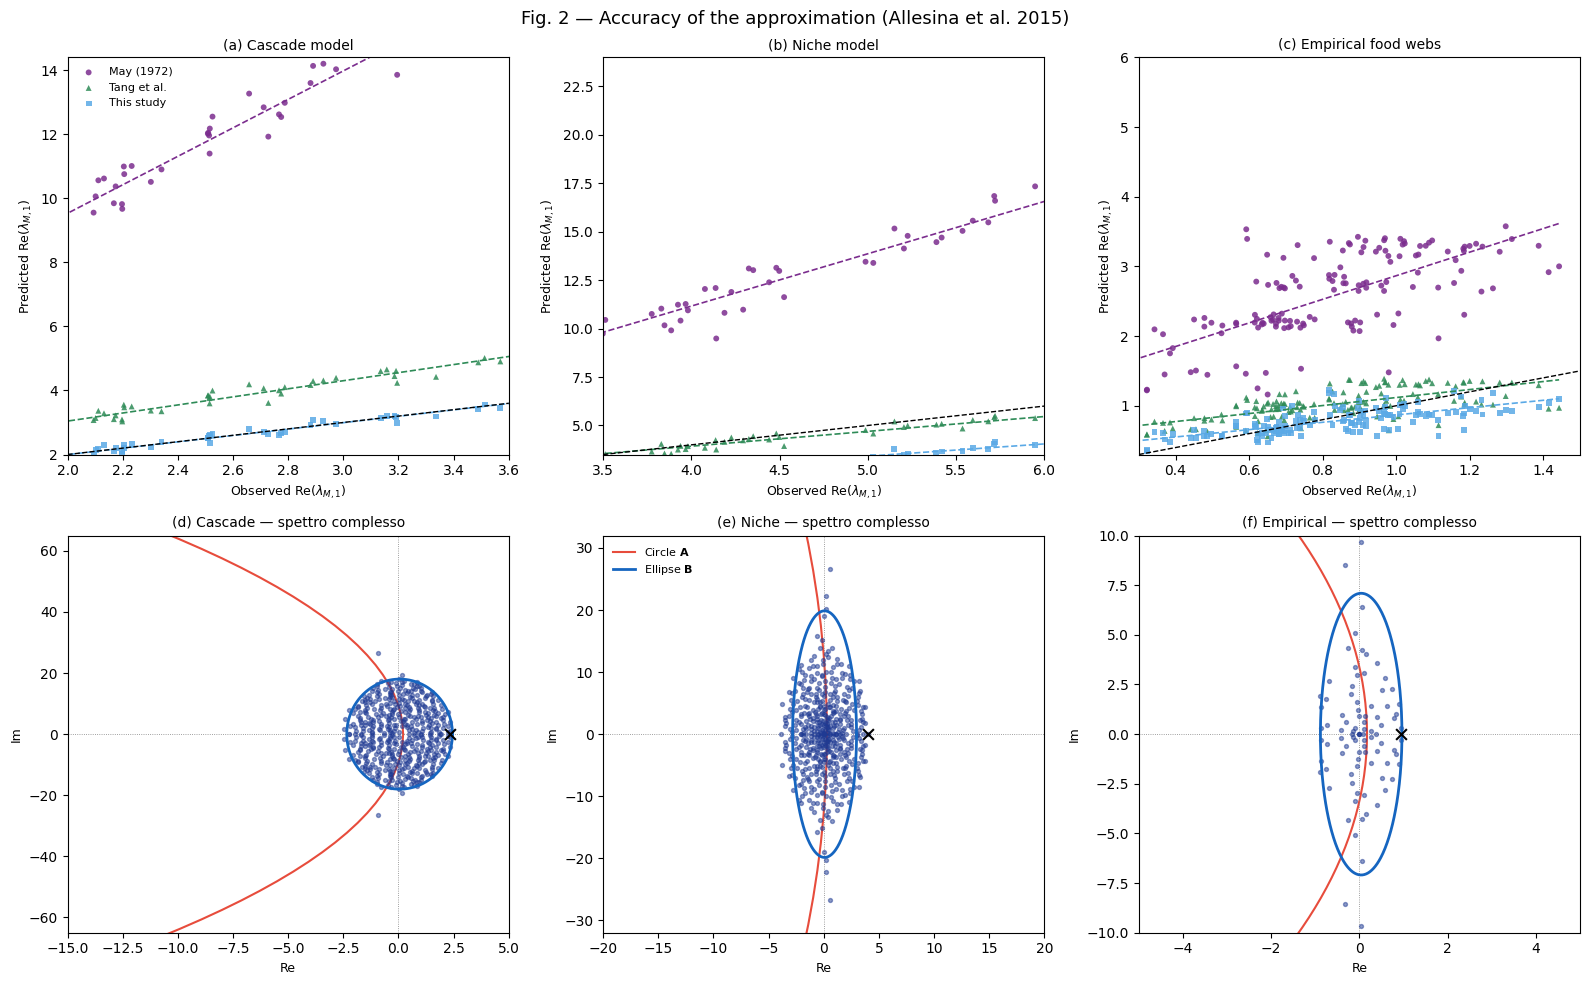

In [20]:

N_CASCADE  = 50    # 150
N_NICHE    = 50    # 150
N_PARAM    = 10    
SEED       = 0

EMPIRICAL_FOOD_WEBS = [
    ("Ythan Estuary",       82,  0.059),
    ("Silwood Park",        154, 0.030),
    ("El Verde",            155, 0.065),
    ("Canton Creek",        108, 0.067),
    ("Stony Stream",        112, 0.065),
    ("Chesapeake Bay",       33, 0.071),
    ("St. Marks",            48, 0.095),
    ("St. Martin Island",    44, 0.116),
    ("Skipwith Pond",        35, 0.315),
    ("Bridge Brook Lake",    25, 0.167),
    ("Little Rock Lake",     92, 0.118),
    ("Mirror Lake",         172, 0.062),
    ("Coachella Valley",     29, 0.312),
    ("Grassland",            61, 0.026),
    ("Benguela Current",     29, 0.260),
]

def run_simulation(model_func, n_matrices, rng, sampler,
                   reorder=False, label=""):
    obs_l, pred_l, tang_l, may_l = [], [], [], []
    for t in range(n_matrices):
        S = int(rng.choice([500, 750, 1000]))
        C = rng.uniform(0.1, 0.3)
        K = model_func(S, C, rng)
        if reorder:
            order = most_upper_triangular_order(K)
            K = K[np.ix_(order, order)]
        M = build_M_from_K(K, sampler, rng)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        obs, _ = leading_eigenvalue_real_part(M)
        pred    = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        nz      = M[M != 0]
        may     = may_criterion(S, C, np.abs(nz).mean(), nz.var())
        tang = tang_criterion(S, C, mu_U, mu_L, sigma_U2/C, sigma_L2/C, rho_UL=-0.67)

        obs_l.append(obs); pred_l.append(pred)
        tang_l.append(tang); may_l.append(may)
        print(f"  [{label}] {t+1:3d}/{n_matrices}  S={S}  C={C:.3f}  obs={obs:.3f}  pred={pred:.3f}")
    return map(np.array, [obs_l, pred_l, tang_l, may_l])

rng     = np.random.default_rng(SEED)
sampler = default_bivariate_sampler()


obs_c, pred_c, tang_c, may_c = run_simulation(
    cascade_model, N_CASCADE, rng, sampler, reorder=False, label="cascade")

print("\n=== Niche model ===")
obs_n, pred_n, tang_n, may_n = run_simulation(
    niche_model, N_NICHE, rng, sampler, reorder=True, label="niche")

print("\n=== Empirical food webs ===")
obs_e_l, pred_e_l, tang_e_l, may_e_l = [], [], [], []
for (name, S, C) in EMPIRICAL_FOOD_WEBS:
    K = niche_model(S, C, rng)
    order = most_upper_triangular_order(K)
    K_r = K[np.ix_(order, order)]
    for rep in range(N_PARAM):
        M = build_M_from_K(K_r, sampler, rng)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        obs, _ = leading_eigenvalue_real_part(M)
        pred    = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        nz      = M[M != 0]
        may     = may_criterion(S, C, np.abs(nz).mean(), nz.var())
        #tang    = tang_criterion(S, C, mu_U, mu_L, sigma_U2/C, sigma_L2/C, rho_UL)
        tang = tang_criterion(S, C, mu_U, mu_L, sigma_U2/C, sigma_L2/C, rho_UL=-0.67)

        obs_e_l.append(obs); pred_e_l.append(pred)
        tang_e_l.append(tang); may_e_l.append(may)
        print(f"  [empirical] {name:20s} rep={rep+1}  obs={obs:.3f}  pred={pred:.3f}")
obs_e, pred_e, tang_e, may_e = map(np.array, [obs_e_l, pred_e_l, tang_e_l, may_e_l])


def compute_spectrum_example(model_func, S=500, C=0.25, reorder=False, seed=1):
    rng_ = np.random.default_rng(seed)
    K = model_func(S, C, rng_)
    if reorder:
        order = most_upper_triangular_order(K)
        K = K[np.ix_(order, order)]
    M = build_M_from_K(K, sampler, rng_)
    mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
    r_A, c_A, re_lA1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, r_v_B     = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    obs, eigvals      = leading_eigenvalue_real_part(M)
    return eigvals, r_A, c_A, re_lA1, r_h_B, r_v_B, obs

S_emp, C_emp = 92, 0.118
rng_emp = np.random.default_rng(99)
K_emp = niche_model(S_emp, C_emp, rng_emp)
order_emp = most_upper_triangular_order(K_emp)
K_emp_r = K_emp[np.ix_(order_emp, order_emp)]
M_emp = build_M_from_K(K_emp_r, sampler, rng_emp)
mu_U_e, mu_L_e, s2U_e, s2L_e, rho_e = triangular_stats(M_emp)
r_A_e, c_A_e, re_lA1_e = spectrum_A_params(S_emp, mu_U_e, mu_L_e)
r_h_B_e, r_v_B_e        = spectrum_B_params(S_emp, s2U_e, s2L_e, rho_e)
obs_emp, eigvals_emp     = leading_eigenvalue_real_part(M_emp)

eigvals_c, r_A_c, c_A_c, re_lA1_c, r_h_B_c, r_v_B_c, obs_c_ex =     compute_spectrum_example(cascade_model, reorder=False, seed=1)
eigvals_ni, r_A_ni, c_A_ni, re_lA1_ni, r_h_B_ni, r_v_B_ni, obs_ni_ex =     compute_spectrum_example(niche_model, reorder=True, seed=1)


def scatter_panel(ax, obs, pred, tang, may, xlim, title):
    def fp(x, y, color, label, marker):
        ax.scatter(x, y, s=18, c=color, label=label, marker=marker,
                   alpha=0.85, edgecolors='none')
        coef = np.polyfit(x, y, 1)
        xs = np.linspace(x.min(), x.max(), 100)
        ax.plot(xs, np.polyval(coef, xs), color=color, ls='--', lw=1.2)
    fp(obs, may,  '#7b2d8e', 'May (1972)', 'o')
    fp(obs, tang, '#2e8b57', 'Tang et al.', '^')
    fp(obs, pred, '#5aa9e6', 'This study', 's')
    ax.plot(list(xlim), list(xlim), 'k--', lw=1)
    ax.set_xlim(xlim); ax.set_ylim(xlim[0], xlim[1]*4)
    ax.set_xlabel(r'Observed Re($\lambda_{M,1}$)', fontsize=9)
    ax.set_ylabel(r'Predicted Re($\lambda_{M,1}$)', fontsize=9)
    ax.set_title(title, fontsize=10)

def spectrum_panel(ax, eigvals, r_A, c_A, re_lA1, r_h_B, r_v_B, obs_val,
                   xlim, ylim, title):
    theta = np.linspace(0, 2*np.pi, 400)
    ax.scatter(eigvals.real, eigvals.imag, s=8, c='#1f3a93', alpha=0.5, zorder=3)
    ax.plot(c_A + r_A*np.cos(theta), r_A*np.sin(theta),
            color='#e74c3c', lw=1.5, label=r'Circle $\mathbf{A}$')
    ax.plot(re_lA1 + r_h_B*np.cos(theta), r_v_B*np.sin(theta),
            color='#1565c0', lw=2, label=r'Ellipse $\mathbf{B}$', zorder=5)
    ax.scatter([obs_val], [0], color='black', marker='x', s=60, zorder=6)
    ax.axvline(0, color='gray', lw=0.6, ls=':')
    ax.axhline(0, color='gray', lw=0.6, ls=':')
    ax.set_xlabel('Re', fontsize=9); ax.set_ylabel('Im', fontsize=9)
    ax.set_xlim(xlim); ax.set_ylim(ylim)
    ax.set_title(title, fontsize=10)

fig, axes = plt.subplots(2, 3, figsize=(16, 10))


scatter_panel(axes[0,0], obs_c,  pred_c,  tang_c,  may_c,  (2, 3.6),
              '(a) Cascade model')
scatter_panel(axes[0,1], obs_n,  pred_n,  tang_n,  may_n,  (3.5, 6),
              '(b) Niche model')
scatter_panel(axes[0,2], obs_e,  pred_e,  tang_e,  may_e,  (0.3, 1.5),
              '(c) Empirical food webs')
axes[0,0].legend(frameon=False, loc='upper left', fontsize=8)


spectrum_panel(axes[1,0], eigvals_c,  r_A_c,  c_A_c,  re_lA1_c,
               r_h_B_c,  r_v_B_c,  obs_c_ex,  (-15,5), (-65,65),
               '(d) Cascade — spettro complesso')
spectrum_panel(axes[1,1], eigvals_ni, r_A_ni, c_A_ni, re_lA1_ni,
               r_h_B_ni, r_v_B_ni, obs_ni_ex, (-20,20), (-32,32),
               '(e) Niche — spettro complesso')
spectrum_panel(axes[1,2], eigvals_emp, r_A_e, c_A_e, re_lA1_e,
               r_h_B_e,  r_v_B_e,  obs_emp,   (-5,5),  (-10,10),
               '(f) Empirical — spettro complesso')
axes[1,1].legend(frameon=False, loc='upper left', fontsize=8)

fig.suptitle('Fig. 2 — Accuracy of the approximation (Allesina et al. 2015)',
             fontsize=13)
fig.tight_layout()
plt.show()


## Figure 3 — Cascade model variants

Comparison of four structural variants: cascade with niche-model degree distribution,
interval cascade, cascade with both properties (= niche model without cycles), niche model.
Reproduction of Fig. 3 from Allesina et al. (2015).

`n_matrices=30` for speed; increase to 150 to replicate the paper.


Saved fig3_reproduction.png


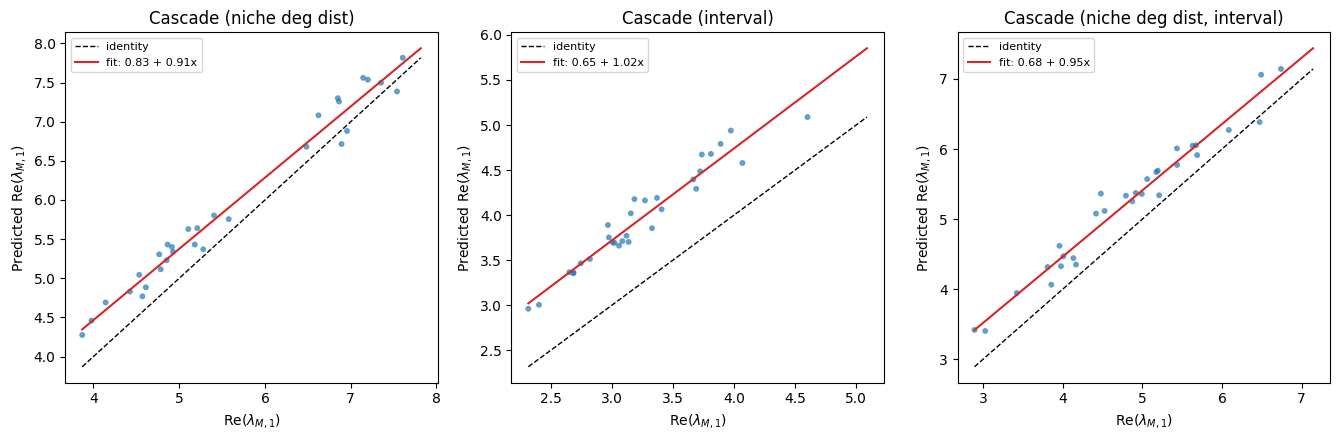

In [ ]:
"""
Reproduces Figure 3 of Allesina et al. 2015, Nature Communications
"Predicting the stability of large structured food webs"

For each of several network-generating models we:
  1. build an adjacency matrix K (cascade model and structured variants)
  2. build a community matrix M by drawing interaction-strength pairs
     (M_ij, M_ji) from a bivariate normal Z=(X,Y) whenever there is a link
  3. compute the OBSERVED Re(lambda_M,1) by direct diagonalization of M
  4. compute the PREDICTED Re(lambda_M,1) using the paper's M = A + B
     decomposition (deterministic "signal" matrix A + random "noise"
     matrix B), using only the first and second moments of M's
     upper/lower-triangular entries -- exactly as described in the
     Methods section ("Spectrum of A and B").
"""

import numpy as np
import matplotlib.pyplot as plt


def cascade_model(S, C, rng):
    K = np.zeros((S, S), dtype=bool)
    for j in range(1, S):
        K[:j, j] = rng.random(j) < C
    return K

def niche_model(S, C, rng, max_attempts=30):
    beta = max((1 - 2 * C) / (2 * C), 1e-6)
    K_best, err_best = None, np.inf
    for _ in range(max_attempts):
        n = np.sort(rng.random(S))
        r = n * rng.beta(1.0, beta, size=S)
        r[0] = 0.0
        c = np.empty(S)
        for i in range(S):
            lo = r[i] / 2.0
            hi = min(n[i], 1.0 - r[i] / 2.0)
            if hi < lo:
                hi = lo
            c[i] = rng.uniform(lo, hi)
        low, high = c - r / 2.0, c + r / 2.0
        K = np.zeros((S, S), dtype=bool)
        for j in range(S):
            prey = np.where((n >= low[j]) & (n <= high[j]))[0]
            prey = prey[prey != j]
            K[prey, j] = True
        realized_C = K.sum() / (S * (S - 1))
        err = abs(realized_C - C)
        if err < err_best:
            K_best, err_best = K, err
        if 0.6 * C <= realized_C <= 1.4 * C:
            return K
    return K_best

def cascade_with_target_degree(S, target_degrees, rng):
    K = np.zeros((S, S), dtype=bool)
    for j in range(S):
        max_prey = j
        k = int(min(target_degrees[j], max_prey))
        if k > 0:
            prey = rng.choice(max_prey, size=k, replace=False)
            K[prey, j] = True
    return K

def cascade_interval(S, C, rng, degree_source=None):
    K = np.zeros((S, S), dtype=bool)
    for j in range(S):
        max_prey = j
        if max_prey == 0:
            continue
        if degree_source is None:
            k = rng.binomial(max_prey, C)
        else:
            k = int(min(rng.choice(degree_source), max_prey))
        if k > 0:
            start = rng.integers(0, max_prey - k + 1)
            K[start:start + k, j] = True
    return K

def consumer_degrees(K):
    return K.sum(axis=0)

def build_M(K, mx, my, sx, sy, rho, rng):
    S = K.shape[0]
    M = np.zeros((S, S))
    prey, pred = np.where(K)
    n_links = len(prey)
    cov = [[sx ** 2, rho * sx * sy], [rho * sx * sy, sy ** 2]]
    XY = rng.multivariate_normal([mx, my], cov, size=n_links)
    M[prey, pred] = XY[:, 0]
    M[pred, prey] = XY[:, 1]
    return M

def matrix_moments(M):
    S = M.shape[0]
    iu, ju = np.triu_indices(S, k=1)
    U = M[iu, ju]
    L = M[ju, iu]
    mU, mL = U.mean(), L.mean()
    sU, sL = U.std(), L.std()
    if sU > 0 and sL > 0:
        rhoUL = np.corrcoef(U, L)[0, 1]
    else:
        rhoUL = 0.0
    return mU, mL, sU, sL, rhoUL

def re_lambda_A1(S, mU, mL):
    A = np.empty((S, S))
    A.fill(mL)
    iu = np.triu_indices(S, k=1)
    A[iu] = mU
    np.fill_diagonal(A, 0.0)
    eig = np.linalg.eigvals(A)
    return eig.real.max()

def re_lambda_B1(S, sU, sL, rhoUL):
    if sU <= 0 or sL <= 0:
        return 0.0
    if np.isclose(sU, sL):
        a = S * sU ** 2
    else:
        a = S * (sU ** 2 - sL ** 2) / np.log(sU ** 2 / sL ** 2)
    rh = (a + rhoUL * sU * sL * (S - 1)) / np.sqrt(a)
    return rh

def predict_re_lambda_M1(K, mx, my, sx, sy, rho, rng):
    S = K.shape[0]
    M = build_M(K, mx, my, sx, sy, rho, rng)
    mU, mL, sU, sL, rhoUL = matrix_moments(M)
    reA = re_lambda_A1(S, mU, mL)
    reB = re_lambda_B1(S, sU, sL, rhoUL)
    predicted = reA + reB
    observed = np.linalg.eigvals(M).real.max()
    return predicted, observed



def run_panel(model_name, n_networks, S_choices, C_range, Z_params, rng):
    mx, my, sx, sy, rho = Z_params
    predicted_list, observed_list = [], []
    for _ in range(n_networks):
        S = int(rng.choice(S_choices))
        C = rng.uniform(*C_range)

        if model_name == "cascade_niche_degdist":
            K_niche = niche_model(S, C, rng)
            degs = consumer_degrees(K_niche)
            K = cascade_with_target_degree(S, degs, rng)

        elif model_name == "cascade_interval":
            K = cascade_interval(S, C, rng, degree_source=None)

        elif model_name == "cascade_niche_degdist_interval":
            K_niche = niche_model(S, C, rng)
            degs = consumer_degrees(K_niche)
            K = cascade_interval(S, C, rng, degree_source=degs)

        else:
            raise ValueError(model_name)

        pred, obs = predict_re_lambda_M1(K, mx, my, sx, sy, rho, rng)
        predicted_list.append(pred)
        observed_list.append(obs)

    return np.array(observed_list), np.array(predicted_list)


rng = np.random.default_rng(42)

# Interaction-strength distribution Z=(X,Y): example moments quoted
# in the paper (Fig. 4 caption / body-size scaling parameterisation)
Z_PARAMS = dict(mx=-1.0, my=0.35, sx=1.23, sy=0.46, rho=-0.67)

# Network sizes / connectances as in the paper (Fig. 2/3 caption);
# reduce these for a quick test run on a laptop.
S_CHOICES = [500, 750, 1000]
C_RANGE = (0.1, 0.3)
N_NETWORKS = 30  # paper uses ~150; reduce for speed, increase for fidelity

panels = [
    ("cascade_niche_degdist", "Cascade (niche deg dist)"),
    ("cascade_interval", "Cascade (interval)"),
    ("cascade_niche_degdist_interval", "Cascade (niche deg dist, interval)"),
]

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.5))
axes = axes.ravel()

for ax, (key, title) in zip(axes, panels):
    obs, pred = run_panel(key, N_NETWORKS, S_CHOICES, C_RANGE,
                            tuple(Z_PARAMS.values()), rng)

    ax.scatter(obs, pred, s=18, alpha=0.7, edgecolor="none")

    lo = min(obs.min(), pred.min())
    hi = max(obs.max(), pred.max())
    ax.plot([lo, hi], [lo, hi], "k--", lw=1, label="identity")

    # best-fit line, as in the paper
    coeffs = np.polyfit(obs, pred, 1)
    xs = np.linspace(lo, hi, 50)
    ax.plot(xs, np.polyval(coeffs, xs), "-", lw=1.5, color="tab:red",
            label=f"fit: {coeffs[1]:.2f} + {coeffs[0]:.2f}x")

    ax.set_title(title)
    ax.set_xlabel(r"Re($\lambda_{M,1}$)")
    ax.set_ylabel(r"Predicted Re($\lambda_{M,1}$)")
    ax.legend(fontsize=8)

    plt.tight_layout()
    plt.savefig("fig3_reproduction.png", dpi=150)
    print("Saved fig3_reproduction.png")

## Figure 4 — Sensitivity analysis

Predicted Re(λ_M,1) as each parameter is varied (multiplied by θ),
with all other parameters fixed at their base value.
Reproduction of Fig. 4 from Allesina et al. (2015).


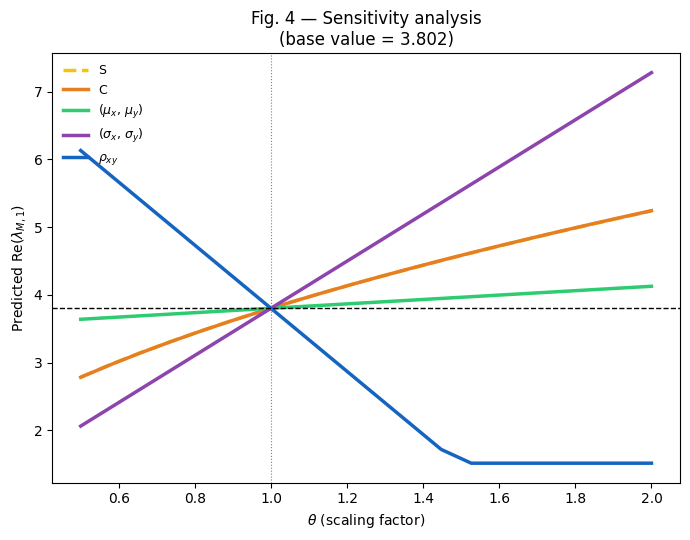

In [6]:
# ── valori base ──
S0, C0         = 1000, 0.1
mu_x0, mu_y0   = -1.0, 0.35
sigma_x0, sigma_y0 = 1.23, 0.46
rho_xy0        = -0.67

theta_values = np.linspace(0.5, 2.0, 20)

def calc(S=S0, C=C0, mu_x=mu_x0, mu_y=mu_y0,
         sigma_x=sigma_x0, sigma_y=sigma_y0, rho_xy=rho_xy0):
    return re_lambda_M1_from_Z_params(S, C, mu_x, mu_y, sigma_x, sigma_y, rho_xy)

curves = {
    'S':                      [calc(S=int(round(S0*th))) for th in theta_values],
    'C':                      [calc(C=min(C0*th, 0.999)) for th in theta_values],
    r'($\mu_x$, $\mu_y$)':   [calc(mu_x=mu_x0*th, mu_y=mu_y0*th) for th in theta_values],
    r'($\sigma_x$, $\sigma_y$)': [calc(sigma_x=sigma_x0*th, sigma_y=sigma_y0*th) for th in theta_values],
    r'$\rho_{xy}$':           [calc(rho_xy=np.clip(rho_xy0*th, -0.999, 0.999)) for th in theta_values],
}
base_value = calc()

# ── plot ──
colors_map = {
    'S':                       '#f1c40f',
    'C':                       '#e67e22',
    r'($\mu_x$, $\mu_y$)':    '#2ecc71',
    r'($\sigma_x$, $\sigma_y$)': '#8e44ad',
    r'$\rho_{xy}$':            '#1565c0',

}

fig, ax = plt.subplots(figsize=(7, 5.5))
for label, ys in curves.items():
    ax.plot(theta_values, ys, label=label, color=colors_map[label],
            linewidth=2.5, linestyle=('--' if label=='S' else '-'))

ax.axhline(base_value, color='black', ls='--', lw=1)
ax.axvline(1.0,        color='gray',  ls=':',  lw=0.8)
ax.set_xlabel(r'$\theta$ (scaling factor)')
ax.set_ylabel(r'Predicted Re($\lambda_{M,1}$)')
ax.set_title(f'Fig. 4 — Sensitivity analysis\n(base value = {base_value:.3f})')
ax.legend(frameon=False, loc='upper left', fontsize=9)
fig.tight_layout()
plt.show()



τ niche originale:   0.964
τ niche riordinata:  0.827


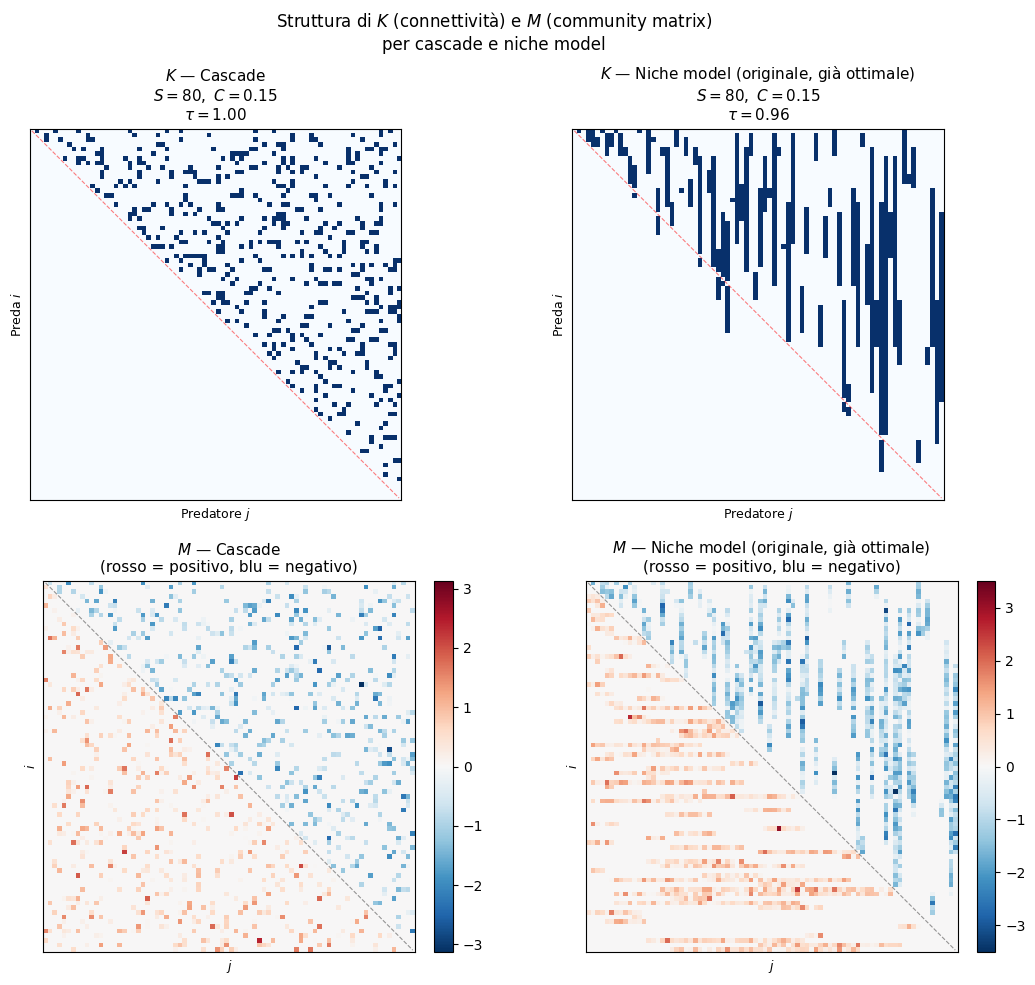

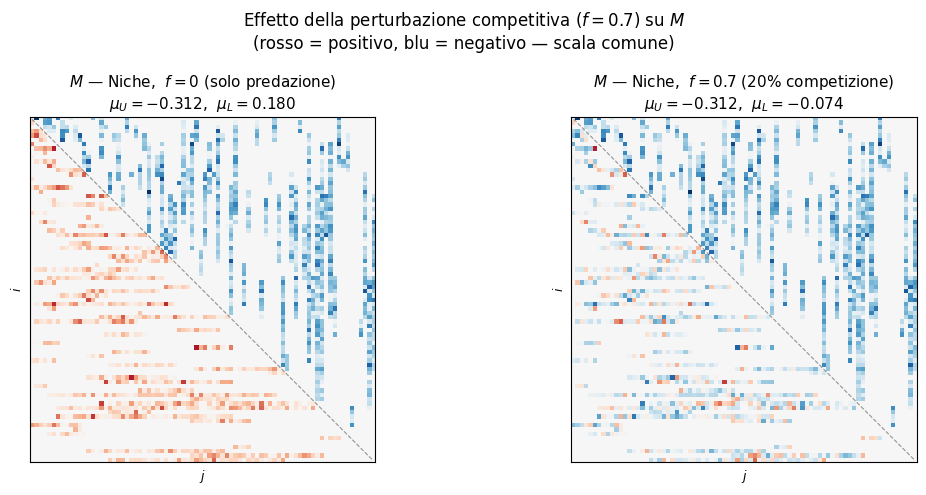

In [ ]:

def triangularity(K):
    S = K.shape[0]
    iu = np.triu_indices(S, k=1)
    il = np.tril_indices(S, k=-1)
    n_upper = K[iu].sum()
    n_lower = K[il].sum()
    total = n_upper + n_lower
    return n_upper / total if total > 0 else 0.5

S_PLOT, C_PLOT = 80, 0.15
SEED_PLOT = 3
rng_plot = np.random.default_rng(SEED_PLOT)
sampler  = default_bivariate_sampler()


K_cascade = cascade_model(S_PLOT, C_PLOT, rng_plot)
M_cascade = build_M_from_K(K_cascade, sampler, rng_plot)


K_niche = niche_model(S_PLOT, C_PLOT, rng_plot)
order   = most_upper_triangular_order(K_niche)
K_niche_ord = K_niche[np.ix_(order, order)]

tau_niche_raw = triangularity(K_niche)
tau_niche_ord = triangularity(K_niche_ord)
print(f"τ niche originale:   {tau_niche_raw:.3f}")
print(f"τ niche riordinata:  {tau_niche_ord:.3f}")

if tau_niche_ord >= tau_niche_raw:
    K_niche_best = K_niche_ord
    label_niche  = "Niche model (riordinata)"
else:
    K_niche_best = K_niche
    label_niche  = "Niche model (originale, già ottimale)"

M_niche = build_M_from_K(K_niche_best, sampler, rng_plot)


fig, axes = plt.subplots(2, 2, figsize=(11, 10))

def plot_K(ax, K, title):
    ax.imshow(K, cmap='Blues', interpolation='nearest', aspect='equal',
              vmin=0, vmax=1)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Predatore $j$', fontsize=9)
    ax.set_ylabel('Preda $i$',    fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, K.shape[1]-1], [0, K.shape[0]-1],
            color='red', lw=0.8, ls='--', alpha=0.5)

def plot_M(ax, M, title):
    vmax = np.abs(M).max()
    im = ax.imshow(M, cmap='RdBu_r', interpolation='nearest',
                   aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$j$', fontsize=9)
    ax.set_ylabel('$i$', fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, M.shape[1]-1], [0, M.shape[0]-1],
            color='black', lw=0.8, ls='--', alpha=0.4)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plot_K(axes[0, 0], K_cascade,
       f'$K$ — Cascade\n$S={S_PLOT},\\ C={C_PLOT}$\n$\\tau={triangularity(K_cascade):.2f}$')
plot_K(axes[0, 1], K_niche_best,
       f'$K$ — {label_niche}\n$S={S_PLOT},\\ C={C_PLOT}$\n$\\tau={triangularity(K_niche_best):.2f}$')

plot_M(axes[1, 0], M_cascade,
       '$M$ — Cascade\n(rosso = positivo, blu = negativo)')
plot_M(axes[1, 1], M_niche,
       f'$M$ — {label_niche}\n(rosso = positivo, blu = negativo)')

fig.suptitle(
    'Struttura di $K$ (connettività) e $M$ (community matrix)\n'
    'per cascade e niche model',
    fontsize=12
)
fig.tight_layout()
plt.show()


F_PERT = 0.4

def sampler_with_competition(f, base_sampler):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

sampler_f0  = sampler_with_competition(0.0,   default_bivariate_sampler())
sampler_f20 = sampler_with_competition(F_PERT, default_bivariate_sampler())

rng0  = np.random.default_rng(SEED_PLOT + 10)
rng20 = np.random.default_rng(SEED_PLOT + 10)

M_f0  = build_M_from_K(K_niche_best, sampler_f0,  rng0)
M_f20 = build_M_from_K(K_niche_best, sampler_f20, rng20)

vmax_pert = max(np.abs(M_f0).max(), np.abs(M_f20).max())

def plot_M_shared(ax, M, title, vmax):
    im = ax.imshow(M, cmap='RdBu_r', interpolation='nearest',
                   aspect='equal', vmin=-vmax, vmax=vmax)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('$j$', fontsize=9)
    ax.set_ylabel('$i$', fontsize=9)
    ax.tick_params(left=False, bottom=False,
                   labelleft=False, labelbottom=False)
    ax.plot([0, M.shape[1]-1], [0, M.shape[0]-1],
            color='black', lw=0.8, ls='--', alpha=0.4)
    return im

fig2, axes2 = plt.subplots(1, 2, figsize=(11, 5))

iu = np.triu_indices(S_PLOT, k=1)
il = np.tril_indices(S_PLOT, k=-1)

im0  = plot_M_shared(axes2[0], M_f0,
                     f'$M$ — Niche,  $f=0$ (solo predazione)\n'
                     f'$\\mu_U={M_f0[iu].mean():.3f}$,  '
                     f'$\\mu_L={M_f0[il].mean():.3f}$',
                     vmax_pert)
im20 = plot_M_shared(axes2[1], M_f20,
                     f'$M$ — Niche,  $f={F_PERT}$ (20% competizione)\n'
                     f'$\\mu_U={M_f20[iu].mean():.3f}$,  '
                     f'$\\mu_L={M_f20[il].mean():.3f}$',
                     vmax_pert)

#fig2.colorbar(im20, ax=axes2.tolist(), fraction=0.02, pad=0.04)
fig2.suptitle(
    f'Effetto della perturbazione competitiva ($f={F_PERT}$) su $M$\n'
    '(rosso = positivo, blu = negativo — scala comune)',
    fontsize=12
)
fig2.tight_layout()
plt.show()

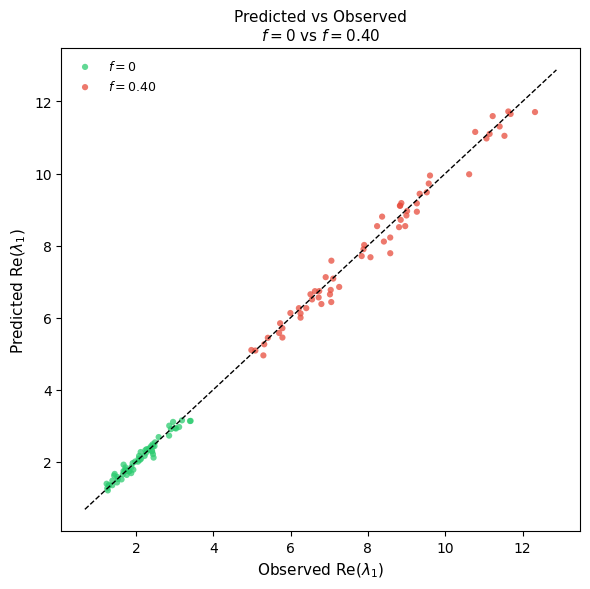

In [ ]:
rng = np.random.default_rng(SEED)
sampler = default_bivariate_sampler()

def sampler_with_competition(f, base_sampler, rng):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

fig, ax = plt.subplots(figsize=(6, 6))

for f_sel, color, label in [(0.0, '#2ecc71', '$f=0$'),
                             (0.40, '#e74c3c', '$f=0.40$')]:
    s_sel = sampler_with_competition(f_sel, sampler, rng)
    obs_l, pred_l = [], []
    rng2 = np.random.default_rng(0)
    for _ in range(60):
        S = int(rng2.choice([300, 500, 750]))
        C = rng2.uniform(0.1, 0.3)
        K = cascade_model(S, C, rng2)
        M = build_M_from_K(K, s_sel, rng2)
        mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
        ratio = (-mu_L / mu_U) if mu_U != 0 else np.nan
        if ratio <= 0 or np.isnan(ratio): continue
        obs, _ = leading_eigenvalue_real_part(M)
        pred   = predict_re_lambda_M1(S, mu_U, mu_L, sigma_U2, sigma_L2, rho_UL)
        obs_l.append(obs); pred_l.append(pred)
    ax.scatter(obs_l, pred_l, s=20, c=color, alpha=0.75,
               edgecolors='none', label=label)

lims = ax.get_xlim()
lo = min(lims[0], ax.get_ylim()[0])
hi = max(lims[1], ax.get_ylim()[1])
ax.plot([lo, hi], [lo, hi], 'k--', lw=1)
ax.set_xlabel(r'Observed Re($\lambda_1$)', fontsize=11)
ax.set_ylabel(r'Predicted Re($\lambda_1$)', fontsize=11)
ax.set_title('Predicted vs Observed\n$f=0$ vs $f=0.40$', fontsize=11)
ax.legend(frameon=False, fontsize=9)

fig.tight_layout()
plt.show()

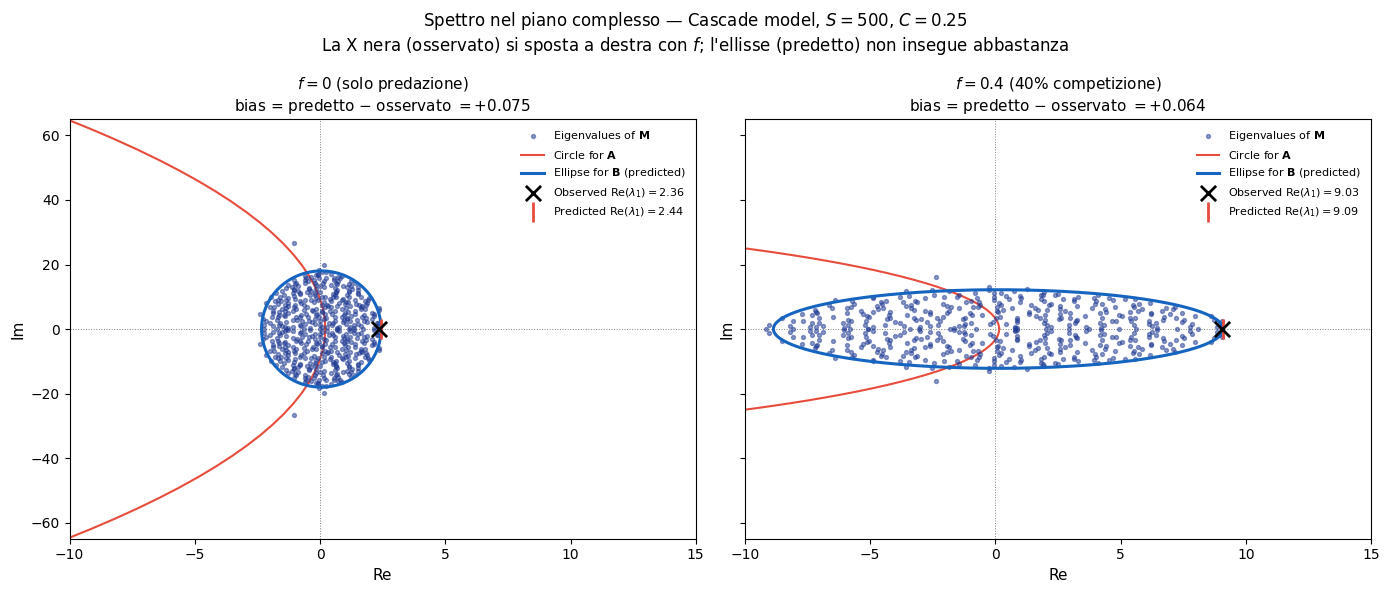

In [ ]:
S, C, SEED = 500, 0.25, 0
F_COMPARE  = 0.4

def sampler_with_competition(f, base_sampler):
    def s(n, rng_inner):
        xy = base_sampler(n, rng_inner)
        flip = rng_inner.random(n) < f
        xy[flip, 1] *= -1
        return xy
    return s

base_sampler = default_bivariate_sampler()

fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
theta = np.linspace(0, 2 * np.pi, 400)

for ax, f in zip(axes, [0.0, F_COMPARE]):
    rng = np.random.default_rng(SEED)   # stesso seed: stessa K, stessa M a meno dei segni
    s_f = sampler_with_competition(f, base_sampler)

    K = cascade_model(S, C, rng)
    M = build_M_from_K(K, s_f, rng)

    mu_U, mu_L, sigma_U2, sigma_L2, rho_UL = triangular_stats(M)
    r_A, c_A, re_lambda_A1 = spectrum_A_params(S, mu_U, mu_L)
    r_h_B, r_v_B           = spectrum_B_params(S, sigma_U2, sigma_L2, rho_UL)
    obs, eigvals            = leading_eigenvalue_real_part(M)
    pred                    = re_lambda_A1 + r_h_B

    ax.scatter(eigvals.real, eigvals.imag, s=8, c='#1f3a93',
               alpha=0.5, label=r'Eigenvalues of $\mathbf{M}$', zorder=3)
    ax.plot(c_A + r_A * np.cos(theta), r_A * np.sin(theta),
            color='#e74c3c', lw=1.5, label=r'Circle for $\mathbf{A}$')
    ax.plot(re_lambda_A1 + r_h_B * np.cos(theta), r_v_B * np.sin(theta),
            color='#1565c0', lw=2.2, label=r'Ellipse for $\mathbf{B}$ (predicted)', zorder=5)
    ax.scatter([obs],  [0], color='black',  marker='x', s=120, lw=2, zorder=7,
               label=fr'Observed $\mathrm{{Re}}(\lambda_1)={obs:.2f}$')
    ax.scatter([pred], [0], color='#e74c3c', marker='|', s=200, lw=2, zorder=6,
               label=fr'Predicted $\mathrm{{Re}}(\lambda_1)={pred:.2f}$')

    ax.axvline(0, color='gray', lw=0.7, ls=':')
    ax.axhline(0, color='gray', lw=0.7, ls=':')
    ax.set_xlabel('Re', fontsize=11)
    ax.set_ylabel('Im', fontsize=11)
    label_f = f'$f=0$ (solo predazione)' if f == 0 else f'$f={f}$ ({int(f*100)}% competizione)'
    bias = pred - obs
    ax.set_title(f'{label_f}\nbias = predetto $-$ osservato $= {bias:+.3f}$', fontsize=11)
    ax.legend(frameon=False, loc='upper right', fontsize=8)

for ax in axes:
    ax.set_xlim(-10, 15)
    ax.set_ylim(-65, 65)

fig.suptitle(
    f'Spettro nel piano complesso — Cascade model, $S={S}$, $C={C}$\n'
    'La X nera (osservato) si sposta a destra con $f$; '
    'l\'ellisse (predetto) non insegue abbastanza',
    fontsize=12
)
fig.tight_layout()
plt.show()